In [1]:
print("Welcome to Python")

Welcome to Python


In [2]:
import pandas as pd

In [3]:
#Let us read dataset

dataset=pd.read_csv("Maternal Health Risk Data Set.csv")

In [4]:
dataset

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [6]:
dataset.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [7]:
import seaborn as sns

<Axes: ylabel='count'>

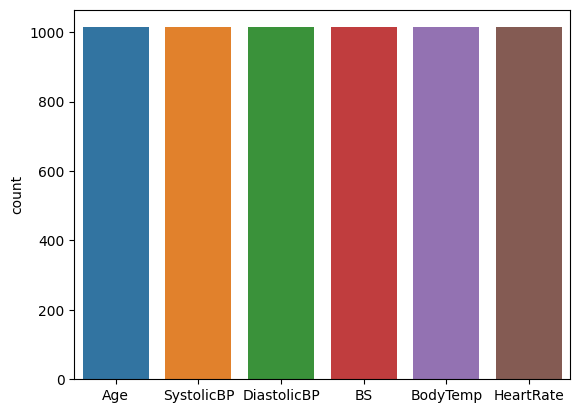

In [8]:
sns.countplot(data=dataset)

<Axes: xlabel='Age', ylabel='Count'>

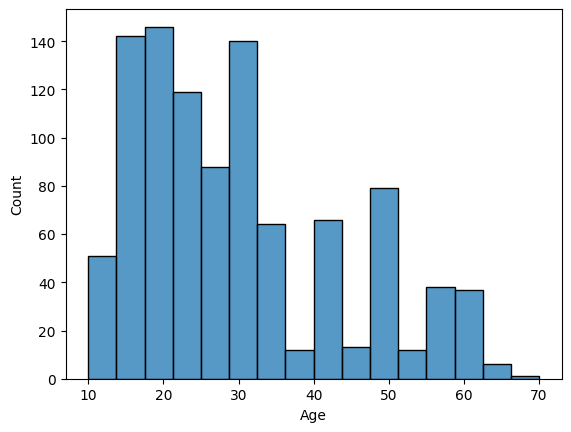

In [9]:
# Let us check distribution of Age column

sns.histplot(data=dataset['Age'])

In [10]:
# Let us Split data into features and target

x=dataset.iloc[:,[0,1,2,3,4,5]].values

In [11]:
x[0]

array([ 25., 130.,  80.,  15.,  98.,  86.])

In [12]:
y=dataset.iloc[:,[6]].values

In [13]:
y[0]

array(['high risk'], dtype=object)

In [14]:
# Let us split data into  training and testing in the ratio 80:20
# this is essential to evaluate model ( i.e accuraccy )

from sklearn.model_selection import train_test_split

In [15]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=50)

In [16]:
# Let us train the model

# Let us use KNN

from sklearn.neighbors import KNeighborsClassifier
model_knn=KNeighborsClassifier()


model_knn.fit(xtrain,ytrain)


c:\python workshop\venv\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
#Let us evalute the model

ypred=model_knn.predict(xtest)


In [18]:
#Let us find out the accuracy

from sklearn.metrics import accuracy_score

knn_score=accuracy_score(ytest,ypred)
print(f"Accuracy score of KNN model is : {knn_score*100}")



Accuracy score of KNN model is : 67.48768472906403


In [19]:
# Let us preprocess the data


mapping = {"low risk": 1, "mid risk": 2, "high risk": 3}

dataset['RiskLevel'] = dataset['RiskLevel'].map(mapping)

In [20]:
dataset

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,3
1,35,140,90,13.0,98.0,70,3
2,29,90,70,8.0,100.0,80,3
3,30,140,85,7.0,98.0,70,3
4,35,120,60,6.1,98.0,76,1
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,3
1010,55,120,90,18.0,98.0,60,3
1011,35,85,60,19.0,98.0,86,3
1012,43,120,90,18.0,98.0,70,3


In [21]:
x=dataset.iloc[:,[0,1,2,3,4,5]].values
y=dataset.iloc[:,[6]].values

In [22]:

import numpy as np

xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=50)

model_knn.fit(xtrain,np.array(ytrain))
ypred=model_knn.predict(xtest)

knn_score=accuracy_score(ytest,ypred)
print(f"Accuracy score of KNN model after pre processing is : {knn_score*100}")


Accuracy score of KNN model after pre processing is : 68.4729064039409


c:\python workshop\venv\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [23]:
#Let us check with Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model=DecisionTreeClassifier()

dt_model.fit( xtrain,np.ravel(ytrain))

ypred=dt_model.predict(xtest)

dt_score=accuracy_score(ytest,ypred)
print(f"Accuracy score of Decision tree model after pre processing is : {dt_score*100}")



Accuracy score of Decision tree model after pre processing is : 81.2807881773399


In [24]:
from sklearn.ensemble import RandomForestClassifier

rfr_model=RandomForestClassifier()


rfr_model.fit( xtrain,np.ravel(ytrain))

ypred=rfr_model.predict(xtest)

rfr_score=accuracy_score(ytest,ypred)

print(f"Accuracy score of Random Forest Classifier after pre processing is : {rfr_score*100}")


print(f"RFR score is : {rfr_model.score(xtrain,ytrain) * 100 }")

Accuracy score of Random Forest Classifier after pre processing is : 80.78817733990148
RFR score is : 93.21824907521578


## Find the difference between

Accuracy score  vs model.score()



In [25]:
#Let us export the model

import joblib
joblib.dump(rfr_model,"maternal_risk_rfrmodel.pkl")

['maternal_risk_rfrmodel.pkl']